<a href="https://colab.research.google.com/github/MuhammadAqsandy/Practical-Statistics-for-Data-Scientist-Books/blob/main/PracticalStatisticsChapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 – Regression & Prediction

## 📖 Summary
Chapter 4 covers **regression models** — the workhorse of predictive modeling. It starts from simple linear regression and extends to multiple regression, polynomial features, regularization, and regression diagnostics.

### Key Topics Covered:
1. **Simple Linear Regression** – fitting a line, OLS
2. **Multiple Linear Regression** – multiple predictors
3. **Evaluating Regression** – R², RMSE, residuals
4. **Cross-Validation** – train/test split, k-fold CV
5. **Model Selection** – stepwise, AIC
6. **Weighted Regression**
7. **Prediction Intervals**
8. **Factor Variables in Regression** – dummy encoding
9. **Interpreting Coefficients** – standardization


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
np.random.seed(42)

# Simulated house price dataset
n = 300
sq_ft   = np.random.uniform(800, 4000, n)
bedrooms = np.random.randint(1, 6, n)
age      = np.random.uniform(0, 50, n)
price    = (120 * sq_ft + 8000 * bedrooms - 500 * age
            + np.random.normal(0, 30000, n))

df = pd.DataFrame({'price': price, 'sq_ft': sq_ft,
                   'bedrooms': bedrooms, 'age': age})
print(df.head())
print(f"\nShape: {df.shape}")


           price        sq_ft  bedrooms        age
0  297149.872919  1998.528380         5  28.454073
1  484065.465396  3842.285781         4   3.175591
2  398200.806352  3142.380614         3   1.841093
3  378761.075794  2715.707149         4   6.692606
4  220785.176317  1299.259649         5   0.683598

Shape: (300, 4)


## 2. Simple Linear Regression

Intercept: 14,348.67
Slope:     119.66
R²:        0.9222


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


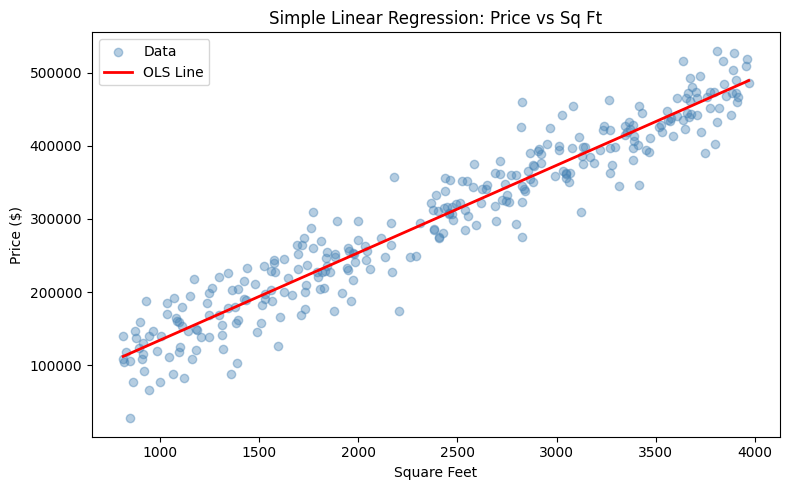

In [2]:
X_simple = df[['sq_ft']]
y = df['price']

model_simple = LinearRegression()
model_simple.fit(X_simple, y)

print(f"Intercept: {model_simple.intercept_:,.2f}")
print(f"Slope:     {model_simple.coef_[0]:,.2f}")
print(f"R²:        {model_simple.score(X_simple, y):.4f}")

# Plot
x_line = np.linspace(sq_ft.min(), sq_ft.max(), 100)
y_line = model_simple.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(df['sq_ft'], df['price'], alpha=0.4, color='steelblue', label='Data')
plt.plot(x_line, y_line, color='red', linewidth=2, label='OLS Line')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.title('Simple Linear Regression: Price vs Sq Ft')
plt.legend()
plt.tight_layout()
plt.savefig('ch4_simple_regression.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Simple Linear Regression
$$y = \beta_0 + \beta_1 x + \epsilon$$

**OLS** (Ordinary Least Squares) minimizes:
$$\text{RSS} = \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

The solution: $\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$, $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$


## 3. Multiple Linear Regression

Coefficients:
  sq_ft     : 118.59
  bedrooms  : 8,194.82
  age       : -475.06

RMSE: 26,752.39
R²:   0.9424


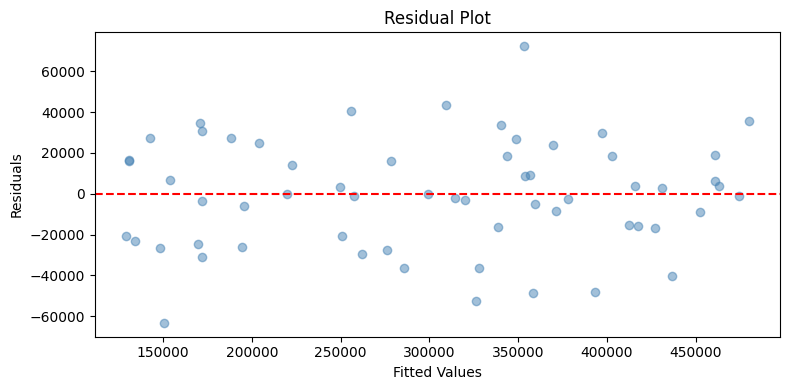

In [3]:
X = df[['sq_ft','bedrooms','age']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Coefficients:")
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name:10s}: {coef:,.2f}")
print(f"\nRMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('ch4_residuals.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Cross-Validation

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean R²:      {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV R² scores: [0.9424 0.9364 0.9346 0.9166 0.9405]
Mean R²:      0.9341 ± 0.0092


## 5. Regularization: Ridge & Lasso

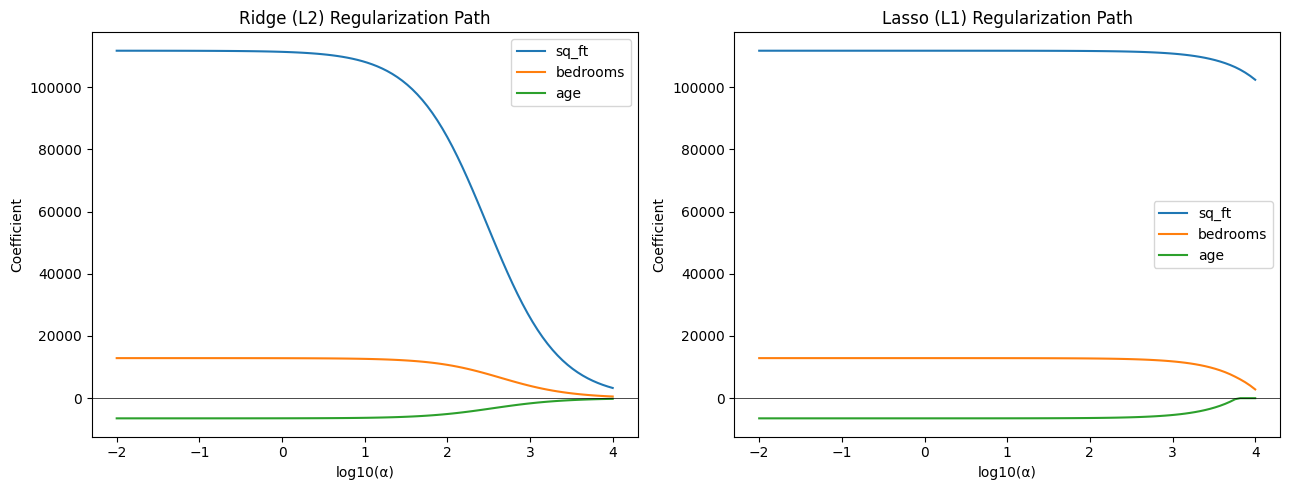

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 4, 100)
ridge_coefs, lasso_coefs = [], []

for a in alphas:
    ridge_coefs.append(Ridge(alpha=a).fit(X_scaled, y).coef_)
    try:
        lasso_coefs.append(Lasso(alpha=a, max_iter=10000).fit(X_scaled, y).coef_)
    except:
        lasso_coefs.append([0]*X.shape[1])

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, col in enumerate(X.columns):
    axes[0].plot(np.log10(alphas), ridge_coefs[:, i], label=col)
    axes[1].plot(np.log10(alphas), lasso_coefs[:, i], label=col)

for ax, title in zip(axes, ['Ridge (L2)','Lasso (L1)']):
    ax.set_xlabel('log10(α)')
    ax.set_ylabel('Coefficient')
    ax.set_title(f'{title} Regularization Path')
    ax.legend()
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('ch4_regularization.png', dpi=100, bbox_inches='tight')
plt.show()


### 📚 Theory: Regularization
Standard OLS can overfit with many features. Regularization adds a **penalty** on coefficient size:

- **Ridge (L2)**: $\min \text{RSS} + \lambda \sum \beta_j^2$ — shrinks all coefficients toward zero.
- **Lasso (L1)**: $\min \text{RSS} + \lambda \sum |\beta_j|$ — can zero out coefficients (feature selection).
- **Elastic Net**: combines both penalties.

As $\lambda$ increases → stronger regularization → simpler model → higher bias, lower variance.


## ✅ Chapter 4 Summary

| Metric | Formula | Interpretation |
|---|---|---|
| RSS | $\sum(y - \hat{y})^2$ | Total squared error |
| RMSE | $\sqrt{\text{MSE}}$ | Error in original units |
| R² | $1 - \text{RSS}/\text{TSS}$ | % variance explained |

**Key takeaway**: Always validate with held-out data or CV. Residual plots are essential — they reveal heteroskedasticity, outliers, and non-linearity.
